<a href="https://colab.research.google.com/github/Sangyii/homework/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

## i am using my google drive mount for the picture
drive.mount('/content/drive')

Mounted at /content/drive


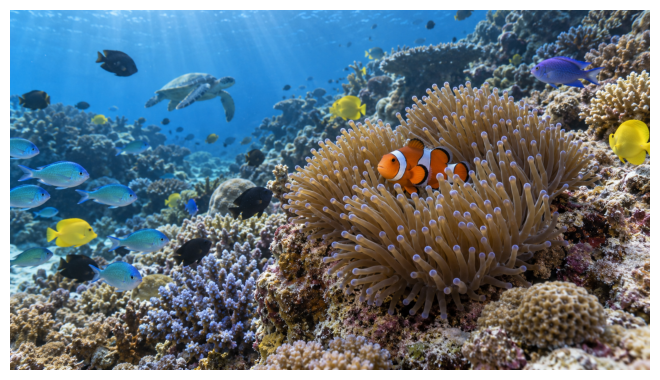

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

## showing the uploaded picture (initial state)
img = Image.open('/content/drive/MyDrive/clown.png')

plt.imshow(img)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

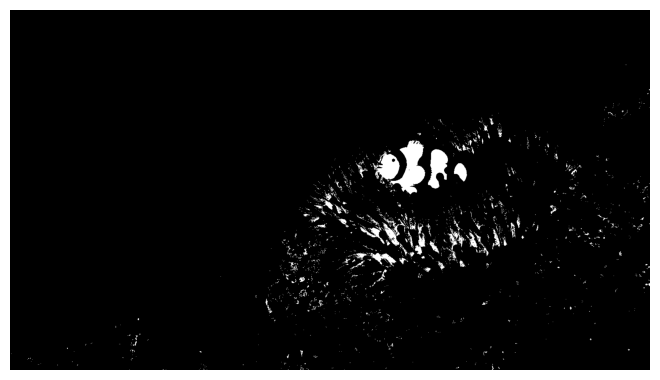


Total dots removed:

White pixels: 31786
Black pixels: 1541566 



In [20]:
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import numpy as np

## converting PIL image open to img.cv (cv2.imread)
img_cv = cv2.imread('/content/drive/MyDrive/clown.png')
hsv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2HSV)

## mask suggested range in HSV format (Minimum -> Maximum)
## find the pixel that is orange, base value -> 0 = black (doesn't match),
## 255 = white (match the range)
lower = np.array([0, 150, 70])
upper = np.array([15, 255, 255])

mask = cv2.inRange(hsv, lower, upper)

## showing mask result
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

print("\nTotal pixels removed:")
print("\nWhite pixels:", np.sum(mask == 255))
print("Black pixels:", np.sum(mask == 0),"\n")

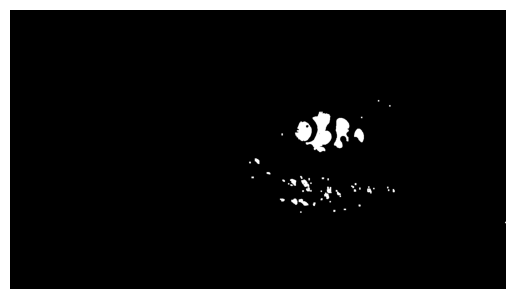

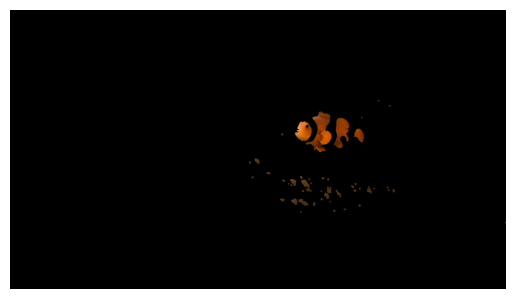

In [21]:
## pixel fix with the hint & some adjustment + result
k = np.ones((5,5), np.uint8)

mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

result = cv2.bitwise_and(img_cv, img_cv, mask=mask)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()